## Importing dependencies

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

## Loading the dataset

In [2]:
gold_df = pd.read_csv('gld_price_data.csv')
gold_df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [5]:
gold_df.shape

(2290, 6)

In [3]:
gold_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


[]

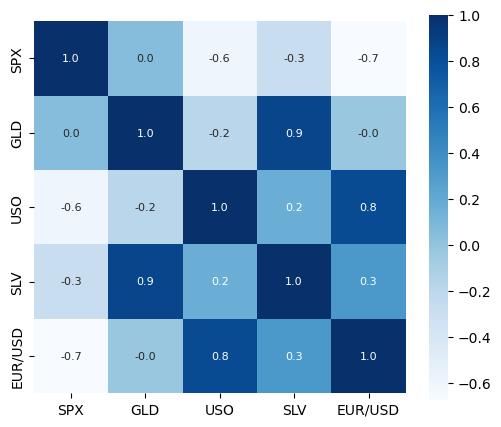

In [20]:
corr = gold_df.drop('Date', axis=1).corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')
plt.plot()

In [21]:
# Correlated values of GLD
print(corr['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


C:\Users\manus\AppData\Local\Temp\ipykernel_24252\3177842735.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_df['GLD'])


<Axes: xlabel='GLD', ylabel='Density'>

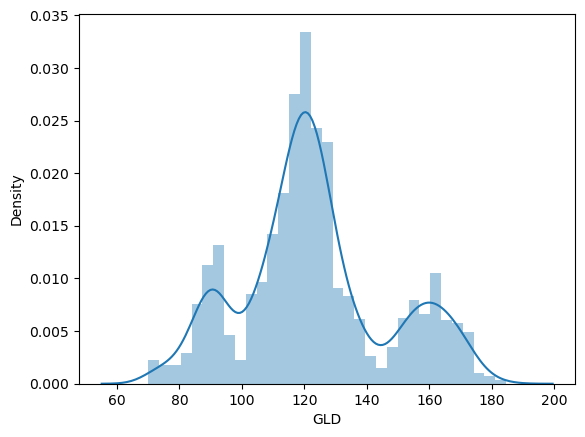

In [22]:
# Distribution of the GOLD/GLD price
sns.distplot(gold_df['GLD'])

## Splitting the data

In [23]:
X = gold_df.drop(['Date','GLD'], axis=1)
Y = gold_df['GLD']

In [24]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

## Training Model

In [28]:
model = RandomForestRegressor(n_estimators=100)

In [29]:
model.fit(X_train, Y_train)

RandomForestRegressor()

## Model Evaluation

In [33]:
# Prediction on training data
train_pred = model.predict(X_train)

# R-squared error
error_score = metrics.r2_score(Y_train, train_pred)
print("R-squared error for training data: ", error_score)

R-squared error for training data:  0.9984141120867545


In [34]:
# Predictio on test data
test_pred = model.predict(X_test)
error_score = metrics.r2_score(Y_test, test_pred)
print("R-squared error for test data: ", error_score)

R-squared error for test data:  0.9888149200149986


## Visualizing the predictions (Actual vs Predicted)

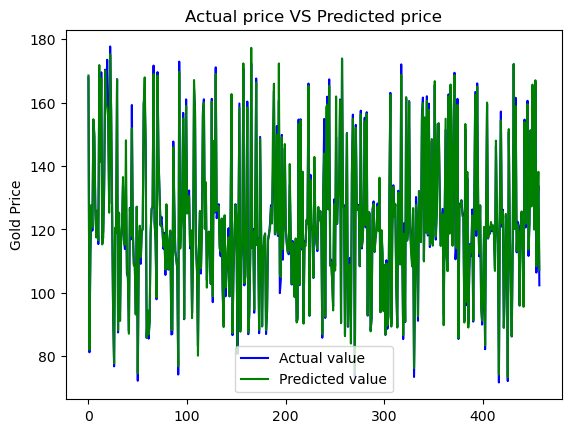

In [37]:
Y_test = list(Y_test)
plt.plot(Y_test, color='blue', label='Actual value')
plt.plot(test_pred, color='green', label='Predicted value')
plt.title("Actual price VS Predicted price")
plt.ylabel("Gold Price")
plt.legend()
plt.show()